In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [10]:
df = pd.read_csv("nextschool_analytics.csv")

df.head()

,ID ребенка,Группа,Диагноз,Возраст,Смена,Педагог
0,Ребенок 1,1,РАС,4,до обеда,Айгерим
1,Ребенок 2,1,"ЗПРР, РАС",5,полный день,Айгерим
2,Ребенок 3,1,ЗПРР,4,до обеда,Айгерим
3,Ребенок 4,1,РАС,4,до обеда,Айгерим
4,Ребенок 5,1,ЗРР,4,полный день,Айгерим


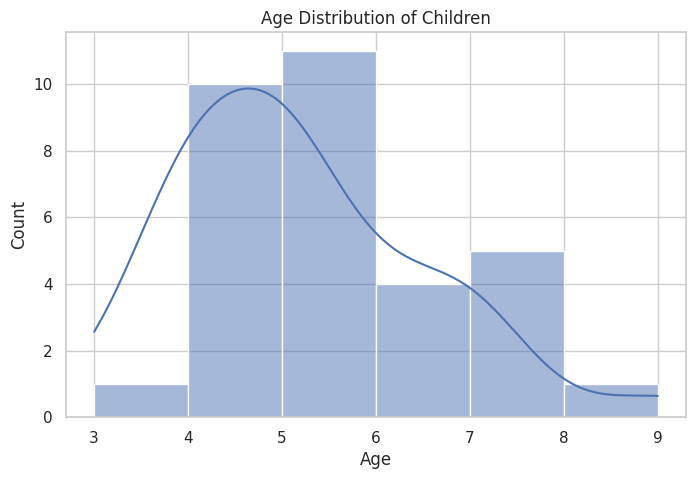

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(df["Возраст"], bins=6, kde=True)
plt.title("Age Distribution of Children")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

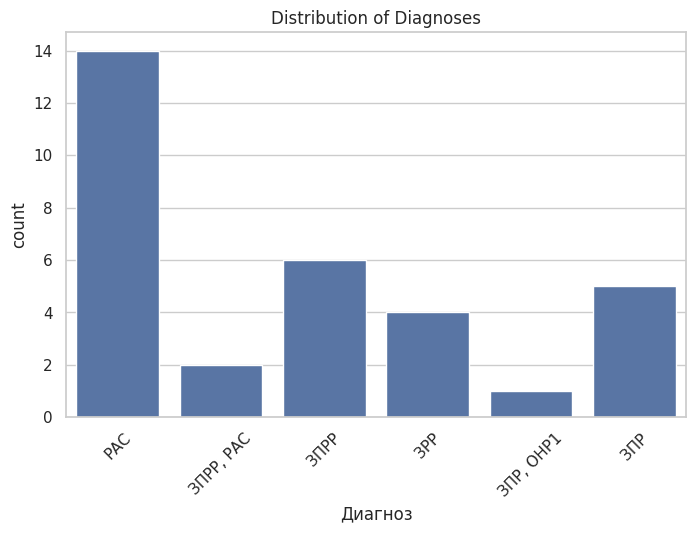

In [14]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="Диагноз")
plt.xticks(rotation=45)
plt.title("Distribution of Diagnoses")
plt.show()

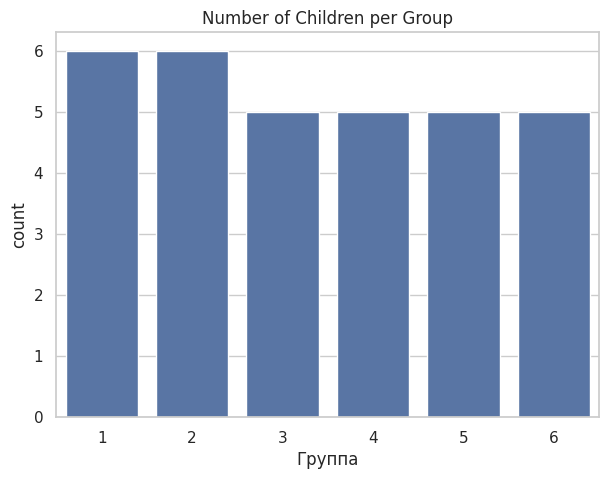

In [15]:
plt.figure(figsize=(7,5))
sns.countplot(data=df, x="Группа")
plt.title("Number of Children per Group")
plt.show()

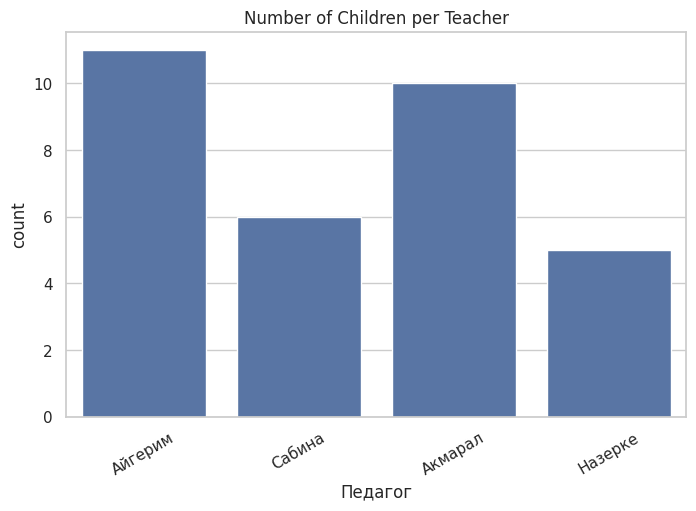

In [16]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="Педагог")
plt.title("Number of Children per Teacher")
plt.xticks(rotation=30)
plt.show()

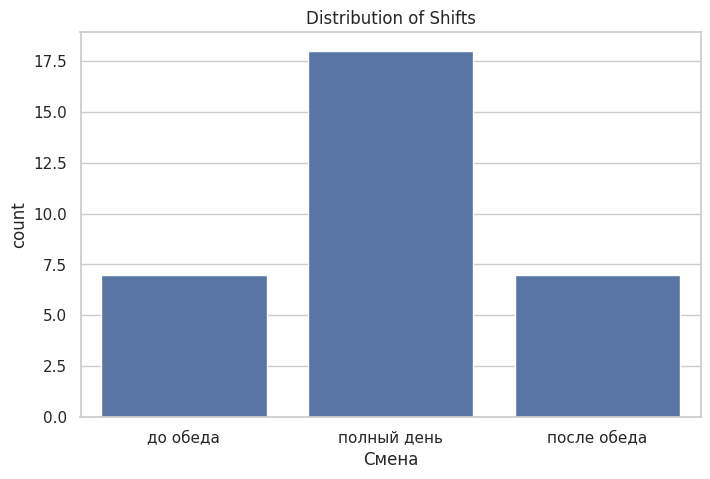

In [17]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="Смена")
plt.title("Distribution of Shifts")
plt.show()

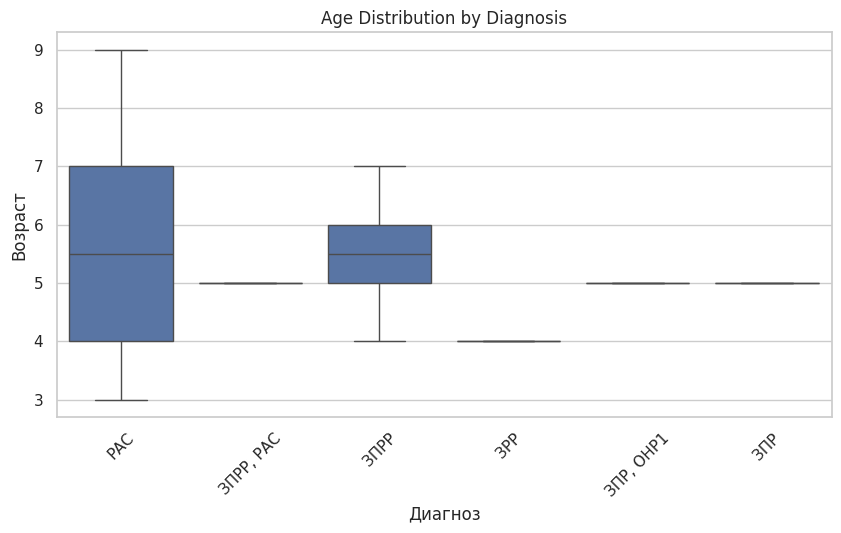

In [18]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x="Диагноз", y="Возраст")
plt.xticks(rotation=45)
plt.title("Age Distribution by Diagnosis")
plt.show()

In [20]:
pd.crosstab(df["Группа"], df["Диагноз"])

Диагноз,ЗПР,"ЗПР, ОНР1",ЗПРР,"ЗПРР, РАС",ЗРР,РАС
Группа,,,,,,
1,0,0,1,1,1,3
2,1,1,0,0,1,3
3,3,0,2,0,0,0
4,1,0,0,0,0,4
5,0,0,3,0,0,2
6,0,0,0,1,2,2


<Axes: >

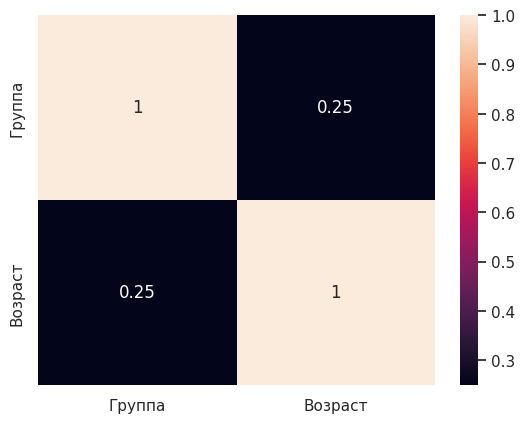

In [21]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

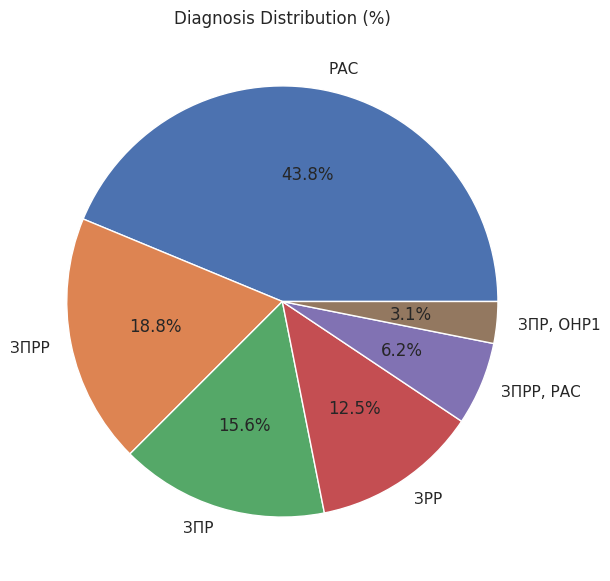

In [22]:
diagnosis_percent = df['Диагноз'].value_counts(normalize=True) * 100

diagnosis_percent.plot(kind='pie', autopct='%1.1f%%', figsize=(7,7))
plt.title("Diagnosis Distribution (%)")
plt.ylabel("")
plt.show()

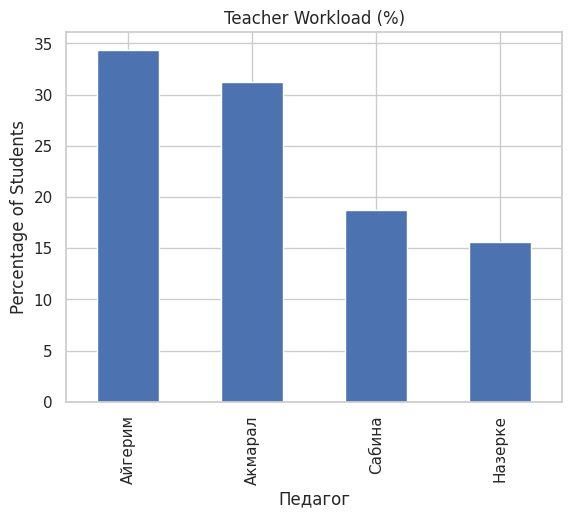

In [24]:
teacher_load = df['Педагог'].value_counts(normalize=True)*100

teacher_load.plot(kind='bar')
plt.title("Teacher Workload (%)")
plt.ylabel("Percentage of Students")
plt.show()

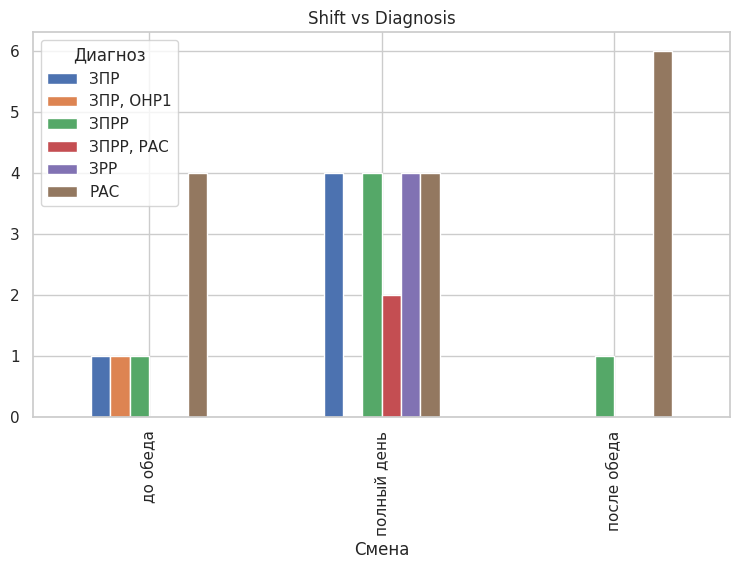

In [25]:
pd.crosstab(df['Смена'], df['Диагноз']).plot(kind='bar', figsize=(9,5))
plt.title("Shift vs Diagnosis")
plt.show()

In [26]:
pivot = pd.pivot_table(
    df,
    values="ID ребенка",
    index="Педагог",
    columns="Диагноз",
    aggfunc="count"
)

pivot

Диагноз,ЗПР,"ЗПР, ОНР1",ЗПРР,"ЗПРР, РАС",ЗРР,РАС
Педагог,,,,,,
Айгерим,1.0,NaN,1.0,1.0,1.0,7.0
Акмарал,3.0,NaN,5.0,NaN,NaN,2.0
Назерке,NaN,NaN,NaN,1.0,2.0,2.0
Сабина,1.0,1.0,NaN,NaN,1.0,3.0


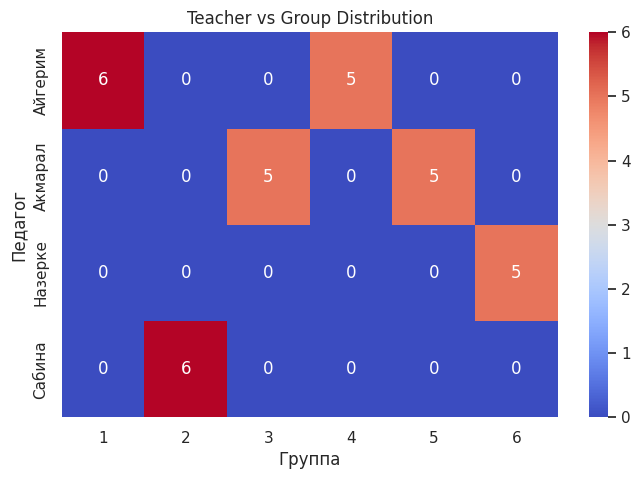

In [28]:
cross = pd.crosstab(df['Педагог'], df['Группа'])

plt.figure(figsize=(8,5))
sns.heatmap(cross, annot=True, cmap="coolwarm")
plt.title("Teacher vs Group Distribution")
plt.show()

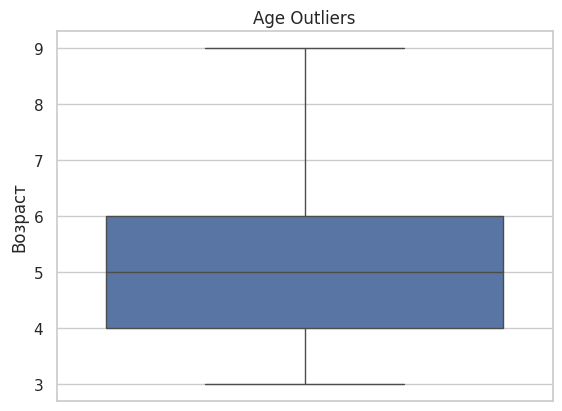

In [29]:
sns.boxplot(y=df["Возраст"])
plt.title("Age Outliers")
plt.show()